In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_excel("FSO_pred_dataset.xlsx")

In [6]:
df

,FSO_Att,RFL_Att,AbsoluteHumidity,AbsoluteHumidityMax,AbsoluteHumidityMin,Distance,Frequency,Particulate,ParticulateMax,ParticulateMin,...,TemperatureMin,Time,Visibility,VisibilityMax,VisibilityMin,WindDirection,WindSpeed,WindSpeedMax,WindSpeedMin,Predicted_FSO_Att
0,8.480261,9.694687,15.930662,17.504117,15.322833,2959.931772,73500000000,0.000000,0.000000,0.000000,...,21.173420,10,50251.391340,52745.193251,47764.908850,84.421790,0.057545,0.462188,0.055872,5.866014
1,3.511600,11.336494,4.884168,5.139645,4.514668,2018.767588,73500000000,0.000000,0.000000,0.000000,...,15.251449,11,19554.715500,19854.670076,18626.944712,95.589421,0.000000,1.720969,0.000000,3.665604
2,6.058910,10.266708,21.586978,22.967831,20.407107,2956.858380,73500000000,0.000000,0.000000,0.000000,...,26.583940,22,15287.325520,16669.585430,14027.718822,91.561005,0.676281,1.113779,0.615111,6.277306
3,6.593463,11.443969,4.074320,4.186823,3.917267,4818.176068,73500000000,0.000000,0.000000,0.000000,...,2.434717,12,25159.573780,25252.272628,24293.881091,32.930082,0.110289,0.175660,0.105458,6.143465
4,6.801351,8.726055,17.840132,19.071630,16.777477,2955.199128,73500000000,0.000000,0.000000,0.000000,...,24.685737,3,30345.736030,33269.672010,28258.151377,95.750686,0.221128,1.290878,0.210291,6.719137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42859,5.450631,13.686893,5.437567,5.841524,5.431575,4825.841905,83500000000,16.957986,18.215495,15.876605,...,5.462535,5,27589.122520,29515.848890,27059.715033,91.460178,0.000000,3.339221,0.000000,5.729101
42860,8.562129,5.726912,18.646348,20.202120,17.269297,2115.649872,73500000000,27.278849,28.111408,25.549803,...,20.526191,22,12247.857120,13280.793041,12142.272075,100.335047,0.692477,1.564934,0.668976,9.310316
42861,5.831768,13.166719,11.384310,11.686584,11.054054,2018.153150,73500000000,174.912616,188.515642,172.608997,...,13.906865,0,7879.930898,8428.066276,7303.756801,106.176817,0.092167,0.170267,0.083516,5.932609
42862,4.798019,13.244202,5.938114,6.182977,5.461478,4819.435242,73500000000,5.954184,5.964829,5.790368,...,6.373556,15,74106.624310,77990.816742,72244.986530,98.457790,0.039269,0.174291,0.037609,4.361835


In [8]:
def recursive_feature_elimination(df, target_col, drop_col=None):
    X = df.drop(columns=[target_col])
    if drop_col and drop_col in X.columns:
        X = X.drop(columns=[drop_col])
    y = df[target_col]

    S = list(X.columns)
    R = []

    while len(S) > 1:
        model = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True, bootstrap=True)
        model.fit(X[S], y)
        y_pred = model.predict(X[S])

        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)

        importances = model.feature_importances_
        least_idx = np.argmin(importances)
        R.append((S[least_idx], rmse, r2))
        S.pop(least_idx)

    # Final feature
    model.fit(X[S], y)
    y_pred = model.predict(X[S])
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    R.append((S[0], rmse, r2))

    return pd.DataFrame(R, columns=["Feature", "RMSE", "R2"])


In [10]:
def plot_feature_elimination(result_df, title, green_line_feature=None):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.grid(True)

    ax1.set_xlabel("Features removed (in order)")
    ax1.set_ylabel("RMSE (dB)", color="tab:blue")
    ax1.plot(result_df['Feature'], result_df['RMSE'], color="tab:blue")
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_xticks(range(len(result_df['Feature'])))
    ax1.set_xticklabels(result_df['Feature'], rotation=90)

    ax2 = ax1.twinx()
    ax2.set_ylabel("R² Score", color="tab:orange")
    ax2.plot(result_df['Feature'], result_df['R2'], color="tab:orange")
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    if green_line_feature in result_df['Feature'].values:
        idx = result_df[result_df['Feature'] == green_line_feature].index[0]
        ax1.axvline(x=idx, color='green', linestyle='dotted', linewidth=2)

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [12]:
# === Run for RFL_Att ===
fso_result = recursive_feature_elimination(df, target_col='RFL_Att', drop_col='FSO_Att')

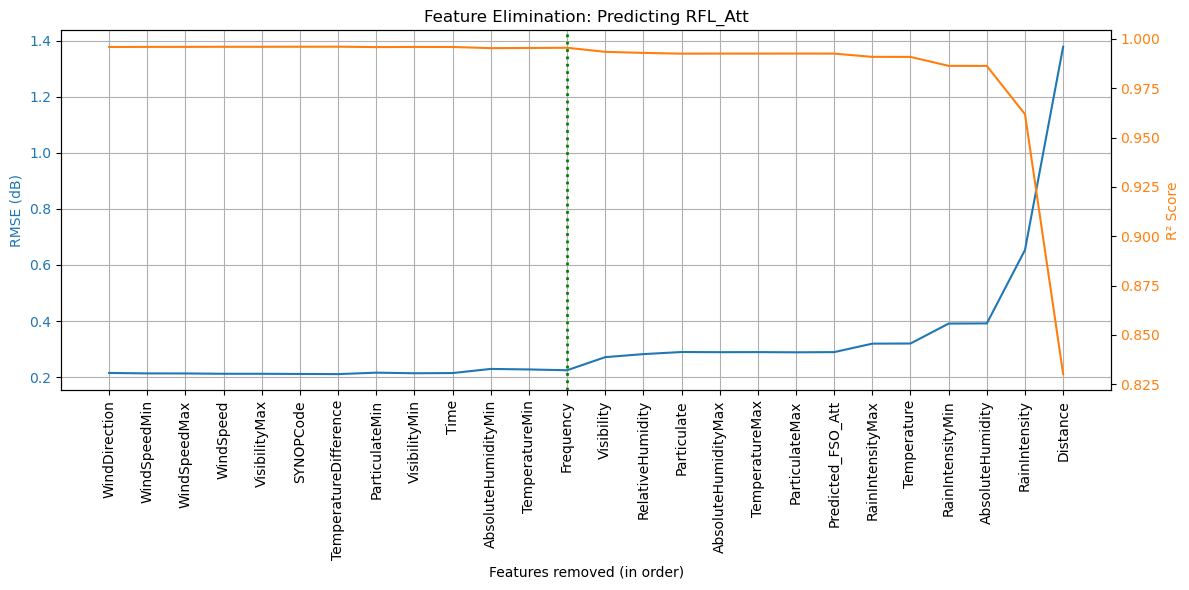

In [18]:
plot_feature_elimination(fso_result, "Feature Elimination: Predicting RFL_Att", green_line_feature="Frequency")

In [20]:
selected_features = [
    'Distance', 'RainIntensity', 'AbsoluteHumidity', 'RainIntensityMin', 'Temperature', 'Predicted_FSO_Att',
    'RAinIntensityMax', 'ParticulateMax', 'TemperatureMax', 'AbsoluteHumidityMAx', 'Particulate',
    'RelativeHumidity', 'Visibility', 'Frequency','RFL_Att'
]

# Filter only the selected features (if they exist in the dataset)
filtered_df = df[[col for col in selected_features if col in df.columns]]

In [24]:
X = filtered_df.drop(columns=["RFL_Att"])
y = filtered_df["RFL_Att"]

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [28]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, None],
    'min_samples_split': [2],
    'max_features': ['sqrt']
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'max_features': ['sqrt'],
                         'min_samples_split': [2], 'n_estimators': [50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [31]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}


In [32]:
best_model_2 = grid_search.best_estimator_
best_model_2.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', random_state=42)

In [36]:
y_train_pred = best_model_2.predict(X_train)
y_val_pred = best_model_2.predict(X_val)

In [38]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

In [40]:
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

In [42]:
print(f"Training RMSE: {rmse_train:.4f}, Validation RMSE: {rmse_val:.4f}")
print(f"Training R²: {r2_train:.4f}, Validation R²: {r2_val:.4f}")

Training RMSE: 0.2429, Validation RMSE: 0.6776
Training R²: 0.9947, Validation R²: 0.9586


In [44]:
test_df = pd.read_excel('test_FSO_dataset_with_predictions.xlsx')

In [46]:
filtered_test_df = test_df[[col for col in selected_features if col in test_df.columns]]

In [48]:
X_test = filtered_test_df.drop(columns=["RFL_Att"])
y_test = filtered_test_df["RFL_Att"]

In [52]:
y_test_pred = best_model_2.predict(X_test)

In [55]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [57]:
print(f"Testing RMSE: {rmse_test:.4f}")
print(f"Testing R²: {r2_test:.4f}")

Testing RMSE: 0.6834
Testing R²: 0.9601
